# OneHotEncoding
we use it for nominal data .
we create columns for all categories and the category that we want 
to select we use 1 in that a and take zeroes in all categories 

basically = we are changing strings into vector format
ex = [1,0,0],[0,1,0],[0,0,1]


no of categories = no of columns


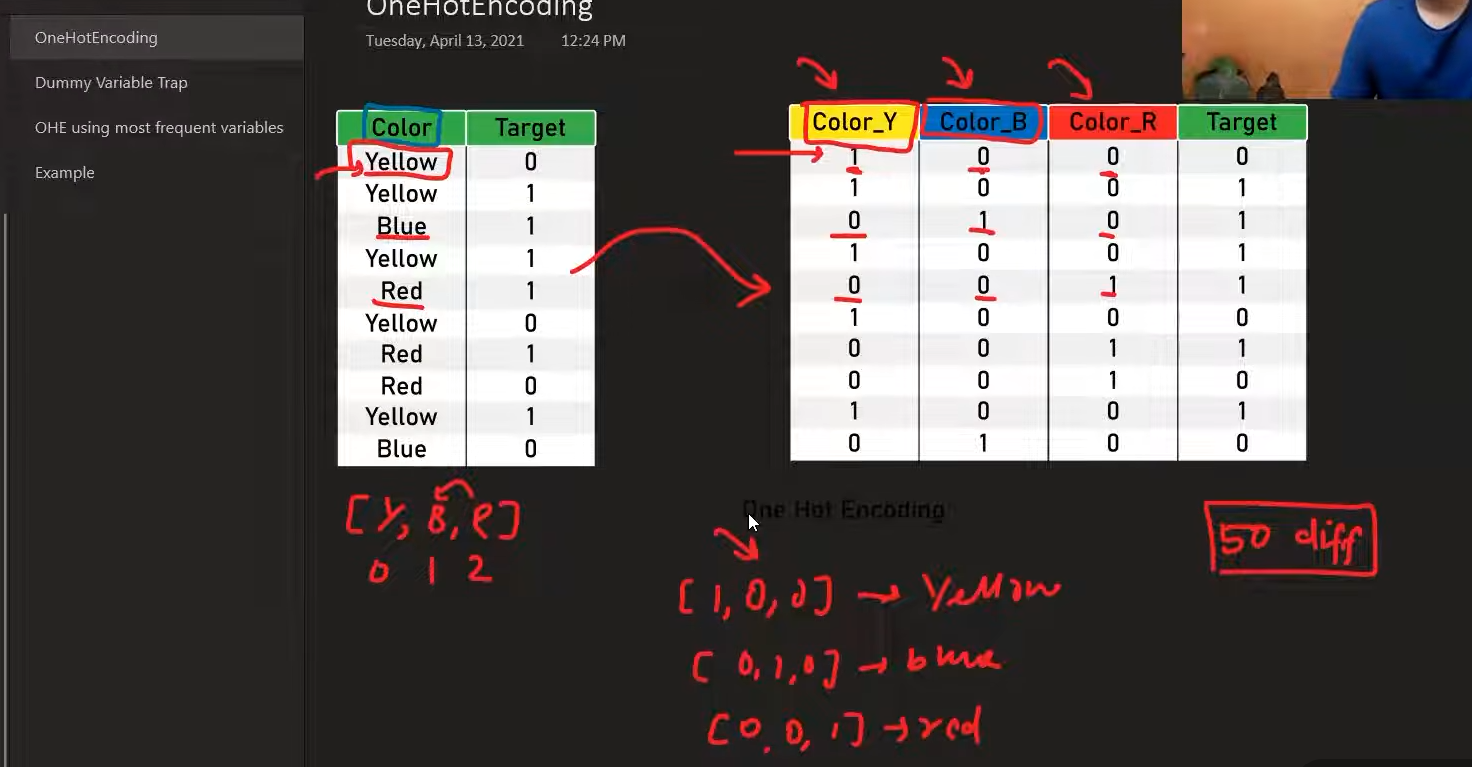



# Dumy variable trap

After oneHot encoding  we remove one column[category] of it.

Multicolinarity = In our machine Learning input columns should be independent of each other.


* so after OHE if we have n category then we remove one column and keep  (n-1) category coz we can 
represent easily but if we don't remove this there can be high chances of mulitcolinarity .

we call these columns as dumivariable.



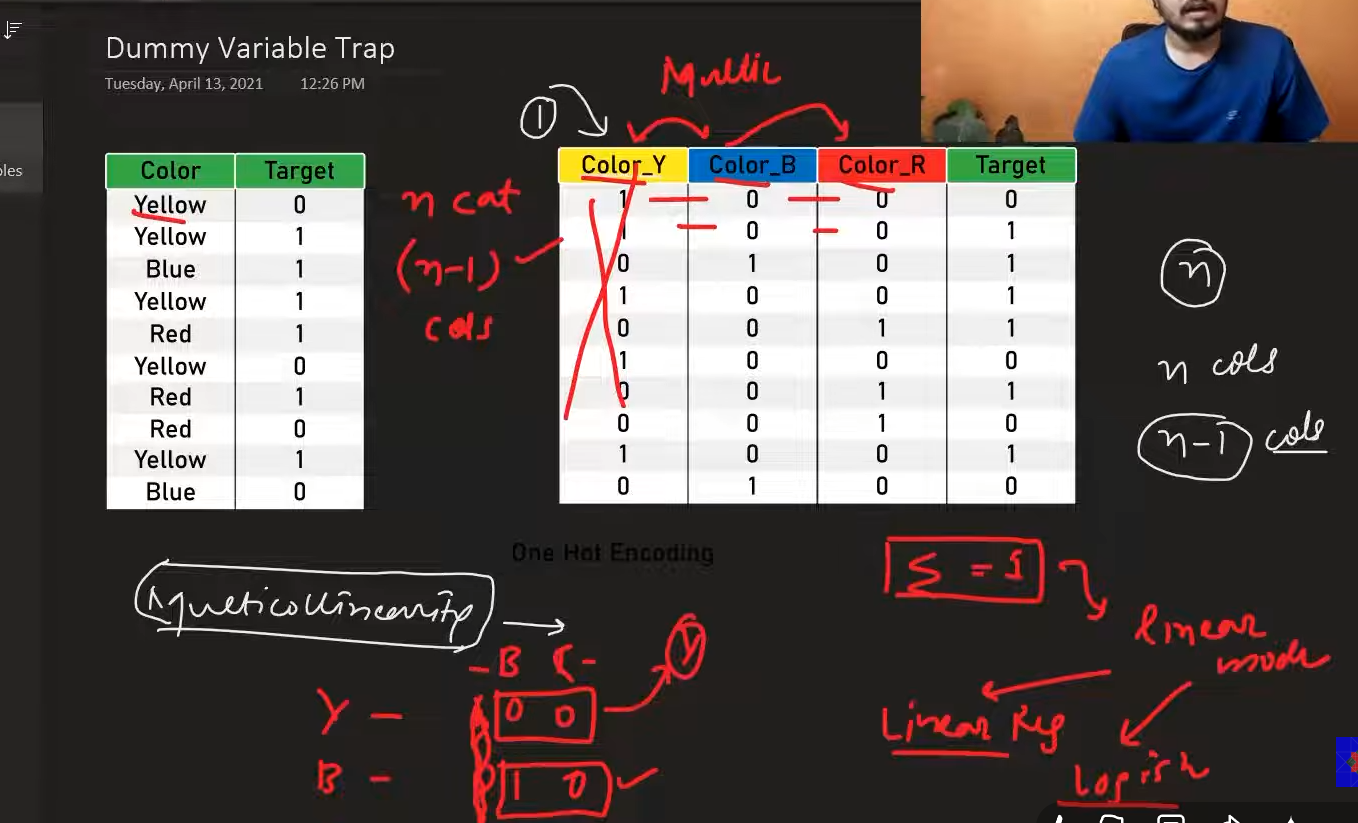

# OHE using most frequent variables

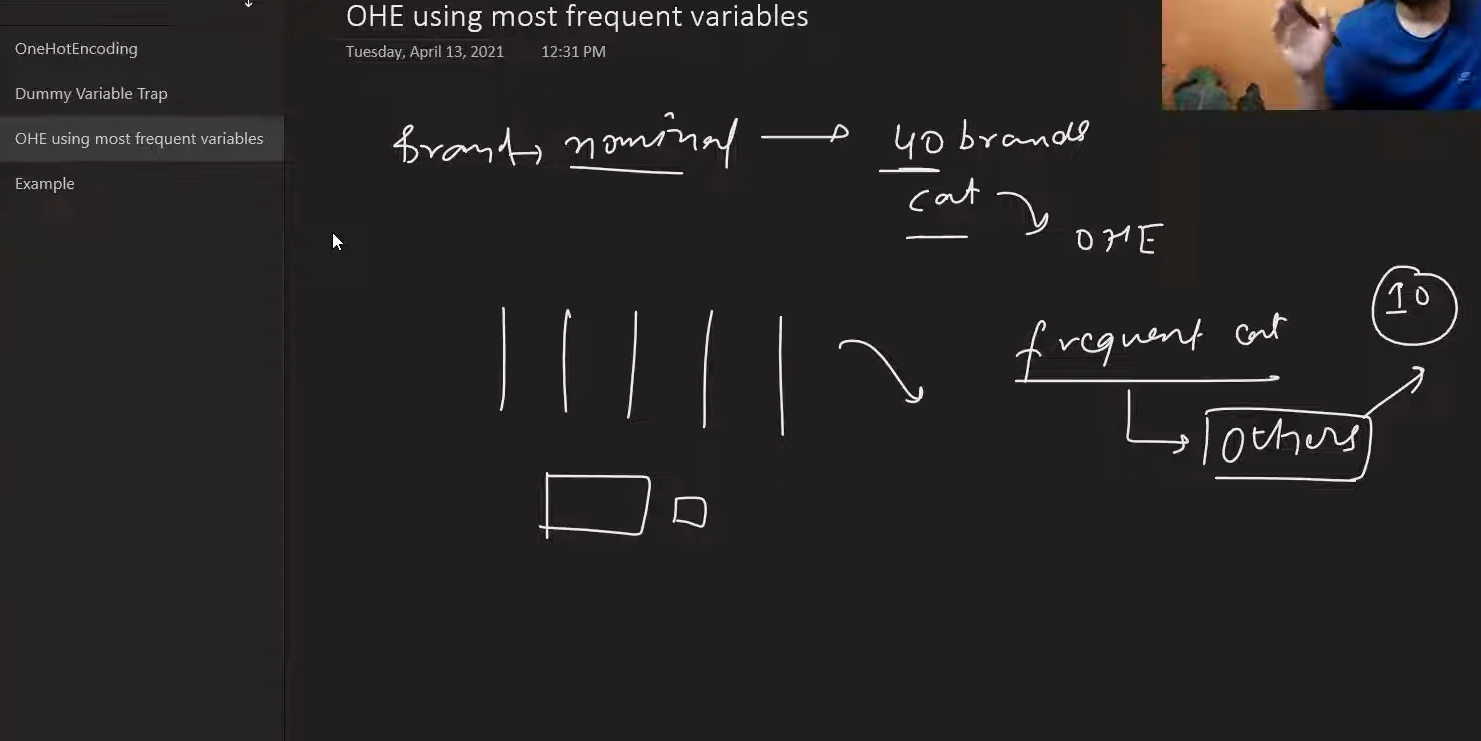

if we have multiple categories so the most frequent categories we create there different different 
columns and those few categories will be in on column[ ex = others]
this is how u reduce ur dimensionality of data sets.

assumption = if some categories are coming high and some less then we can use this approach 



In [43]:
import numpy as np
import pandas as pd

url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day27-one-hot-encoding/cars.csv"
df = pd.read_csv(url)

In [8]:
df.sample(5)

,brand,km_driven,fuel,owner,selling_price
1911,Maruti,60000,Petrol,First Owner,190000
5373,Mahindra,70000,Diesel,First Owner,1100000
336,Hyundai,60000,Petrol,Second Owner,85000
850,Maruti,58000,Petrol,First Owner,120000
6940,Mahindra,90000,Diesel,First Owner,550000


In [10]:
df['fuel'].value_counts()
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

# OneHotEncoding using pandas

In [14]:
pd.get_dummies(df, columns = ['fuel', 'owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


# k - 1 OneHotEncoding

In [16]:
pd.get_dummies(df,columns = ['fuel','owner'],drop_first = True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


we don't use pandas for onehotencoding in machine learning project coz 
it doesn't remember at which place it put which column

In [18]:
df.head(2)

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000


# OneHotEncoding using SKLearn

In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train , y_test = train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size = 0.2, random_state = 0)

In [32]:
x_train.head(5)

,brand,km_driven,fuel,owner
3042,Hyundai,60000,LPG,First Owner
1520,Tata,150000,Diesel,Third Owner
2611,Hyundai,110000,Diesel,Second Owner
3544,Mahindra,28000,Diesel,Second Owner
4138,Maruti,15000,Petrol,First Owner


In [33]:
from sklearn.preprocessing import OneHotEncoder

In [61]:
one = OneHotEncoder(drop = 'first', dtype=np.int32)

In [62]:
x_train_new = one.fit_transform(x_train[['fuel','owner']]).toarray()
x_test_new = one.fit_transform(x_test[['fuel','owner']]).toarray()

In [63]:
x_train_new

array([[0, 1, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 1],
       [1, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 1, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]], shape=(6502, 7), dtype=int32)

In [64]:
np.hstack((x_train[['brand', 'km_driven']].values,x_train_new))

array([['Hyundai', 60000, 0, ..., 0, 0, 0],
       ['Tata', 150000, 1, ..., 0, 0, 1],
       ['Hyundai', 110000, 1, ..., 1, 0, 0],
       ...,
       ['Hyundai', 90000, 0, ..., 1, 0, 0],
       ['Volkswagen', 90000, 1, ..., 0, 0, 0],
       ['Hyundai', 110000, 0, ..., 0, 0, 0]],
      shape=(6502, 9), dtype=object)

# OneHotEncoding with top categories

In [74]:
counts = df['brand'].value_counts()

In [75]:
df['brand'].nunique()
threshold = 100

In [76]:
repl = counts[counts<= threshold].index


In [81]:
pd.get_dummies(df['brand'].replace(repl,'uncommon'))

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
0,False,False,False,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,False,False,False,False,True,False,False,False,False,False,False,False,False
8124,False,False,False,False,True,False,False,False,False,False,False,False,False
8125,False,False,False,False,False,False,True,False,False,False,False,False,False
8126,False,False,False,False,False,False,False,False,False,True,False,False,False
